# 🍎 Obesity Risk Dataset — EDA & Predictive Modelling

**Goal**: Explore the obesity level data through Exploratory Data Analysis (EDA), and build the **best predictive model** for `Obesity_Level` (multiclass) using cross-validation and hyperparameter tuning, wrapped in a clean scikit-learn `Pipeline`.

> ℹ️ **Note on data cleaning**: The raw CSV shipped with a corrupted column name (`0be1dad`) for the target and corrupted string values (`0rmal_Weight` instead of `Normal_Weight`, and `0` in `CAEC`/`CALC` instead of `Never`). Those are fixed right after loading. The dataset has **no missing values** and no duplicate rows; the non-predictive `id` column is dropped.

---

## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score,
    GridSearchCV, cross_validate
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc, confusion_matrix,
    ConfusionMatrixDisplay, classification_report
)

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

print('Setup complete.')

Setup complete.


## 2. Load the Data (target column name fixed)

In [2]:
data_path = 'obesity_level.csv'
df = pd.read_csv(data_path)

# Fix corrupted column names / values straight away so EDA is clean
df.rename(columns={'0be1dad': 'Obesity_Level'}, inplace=True)
df['Obesity_Level'] = df['Obesity_Level'].replace({'0rmal_Weight': 'Normal_Weight'})
df['CAEC'] = df['CAEC'].replace({'0': 'Never'})
df['CALC'] = df['CALC'].replace({'0': 'Never'})

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()

Shape: (20758, 18)
Columns: ['id', 'Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'Obesity_Level']


,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity_Level
0,0,Male,24.443011,1.699998,81.669950,1,1,2.000000,2.983297,Sometimes,0,2.763573,0,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,1,1,2.000000,3.000000,Frequently,0,2.000000,0,1.000000,1.000000,Never,Automobile,Normal_Weight
2,2,Female,18.000000,1.711460,50.165754,1,1,1.880534,1.411685,Sometimes,0,1.910378,0,0.866045,1.673584,Never,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,1,1,3.000000,3.000000,Sometimes,0,1.674061,0,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,1,1,2.679664,1.971472,Sometimes,0,1.979848,0,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20758 entries, 0 to 20757
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              20758 non-null  int64  
 1   Gender                          20758 non-null  object 
 2   Age                             20758 non-null  float64
 3   Height                          20758 non-null  float64
 4   Weight                          20758 non-null  float64
 5   family_history_with_overweight  20758 non-null  int64  
 6   FAVC                            20758 non-null  int64  
 7   FCVC                            20758 non-null  float64
 8   NCP                             20758 non-null  float64
 9   CAEC                            20758 non-null  object 
 10  SMOKE                           20758 non-null  int64  
 11  CH2O                            20758 non-null  float64
 12  SCC                             

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,20758.0,10378.500000,5992.462780,0.00,5189.250000,10378.500000,15567.750000,20757.000000
Age,20758.0,23.841804,5.688072,14.00,20.000000,22.815416,26.000000,61.000000
Height,20758.0,1.700245,0.087312,1.45,1.631856,1.700000,1.762887,1.975663
Weight,20758.0,87.887768,26.379443,39.00,66.000000,84.064875,111.600553,165.057269
family_history_with_overweight,20758.0,0.819636,0.384500,0.00,1.000000,1.000000,1.000000,1.000000
FAVC,20758.0,0.914443,0.279716,0.00,1.000000,1.000000,1.000000,1.000000
FCVC,20758.0,2.445908,0.533218,1.00,2.000000,2.393837,3.000000,3.000000
NCP,20758.0,2.761332,0.705375,1.00,3.000000,3.000000,3.000000,4.000000
SMOKE,20758.0,0.011803,0.108000,0.00,0.000000,0.000000,0.000000,1.000000
CH2O,20758.0,2.029418,0.608467,1.00,1.792022,2.000000,2.549617,3.000000


## 3. Exploratory Data Analysis (EDA)

### 3.1 Target Variable Distribution

Obesity_Level
Obesity_Type_III       4046
Obesity_Type_II        3248
Normal_Weight          3082
Obesity_Type_I         2910
Insufficient_Weight    2523
Overweight_Level_II    2522
Overweight_Level_I     2427
Name: count, dtype: int64

Percentage:
Obesity_Level
Obesity_Type_III       19.49
Obesity_Type_II        15.65
Normal_Weight          14.85
Obesity_Type_I         14.02
Insufficient_Weight    12.15
Overweight_Level_II    12.15
Overweight_Level_I     11.69
Name: proportion, dtype: float64


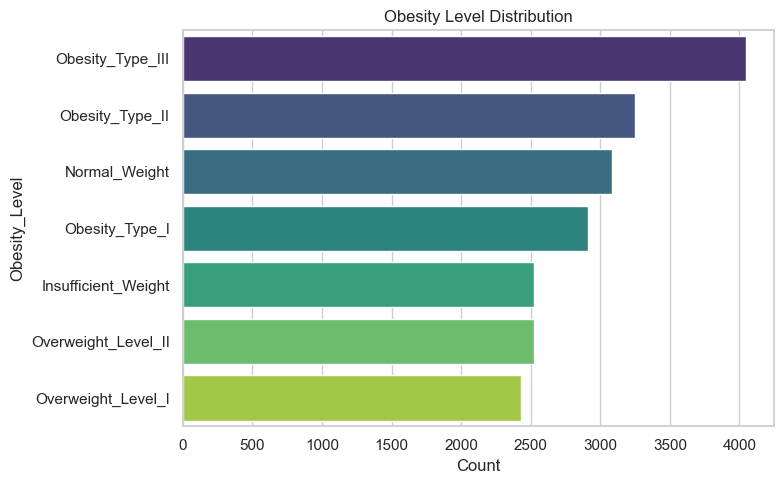

In [5]:
print(df['Obesity_Level'].value_counts())
print('\nPercentage:')
print((df['Obesity_Level'].value_counts(normalize=True) * 100).round(2))

plt.figure(figsize=(8, 5))
sns.countplot(y='Obesity_Level', data=df, order=df['Obesity_Level'].value_counts().index, palette='viridis')
plt.title('Obesity Level Distribution')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

### 3.2 Categorical Features

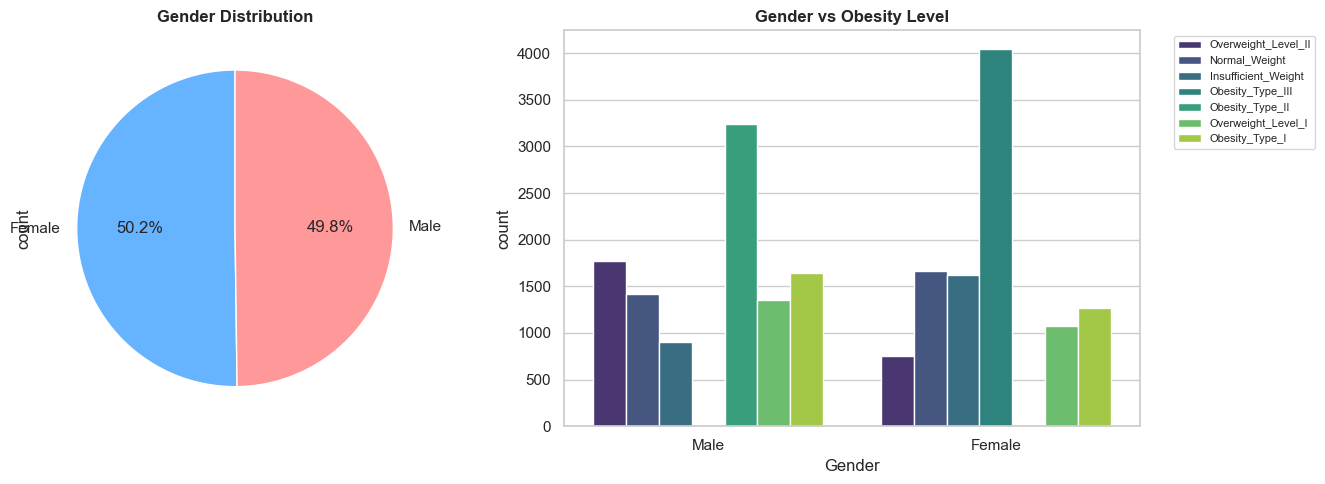

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['Gender'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#66b3ff', '#ff9999'], ax=axes[0], startangle=90)
axes[0].set_title('Gender Distribution', fontweight='bold')

sns.countplot(data=df, x='Gender', hue='Obesity_Level', palette='viridis', ax=axes[1])
axes[1].set_title('Gender vs Obesity Level', fontweight='bold')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

### 3.3 Numerical Feature Distributions

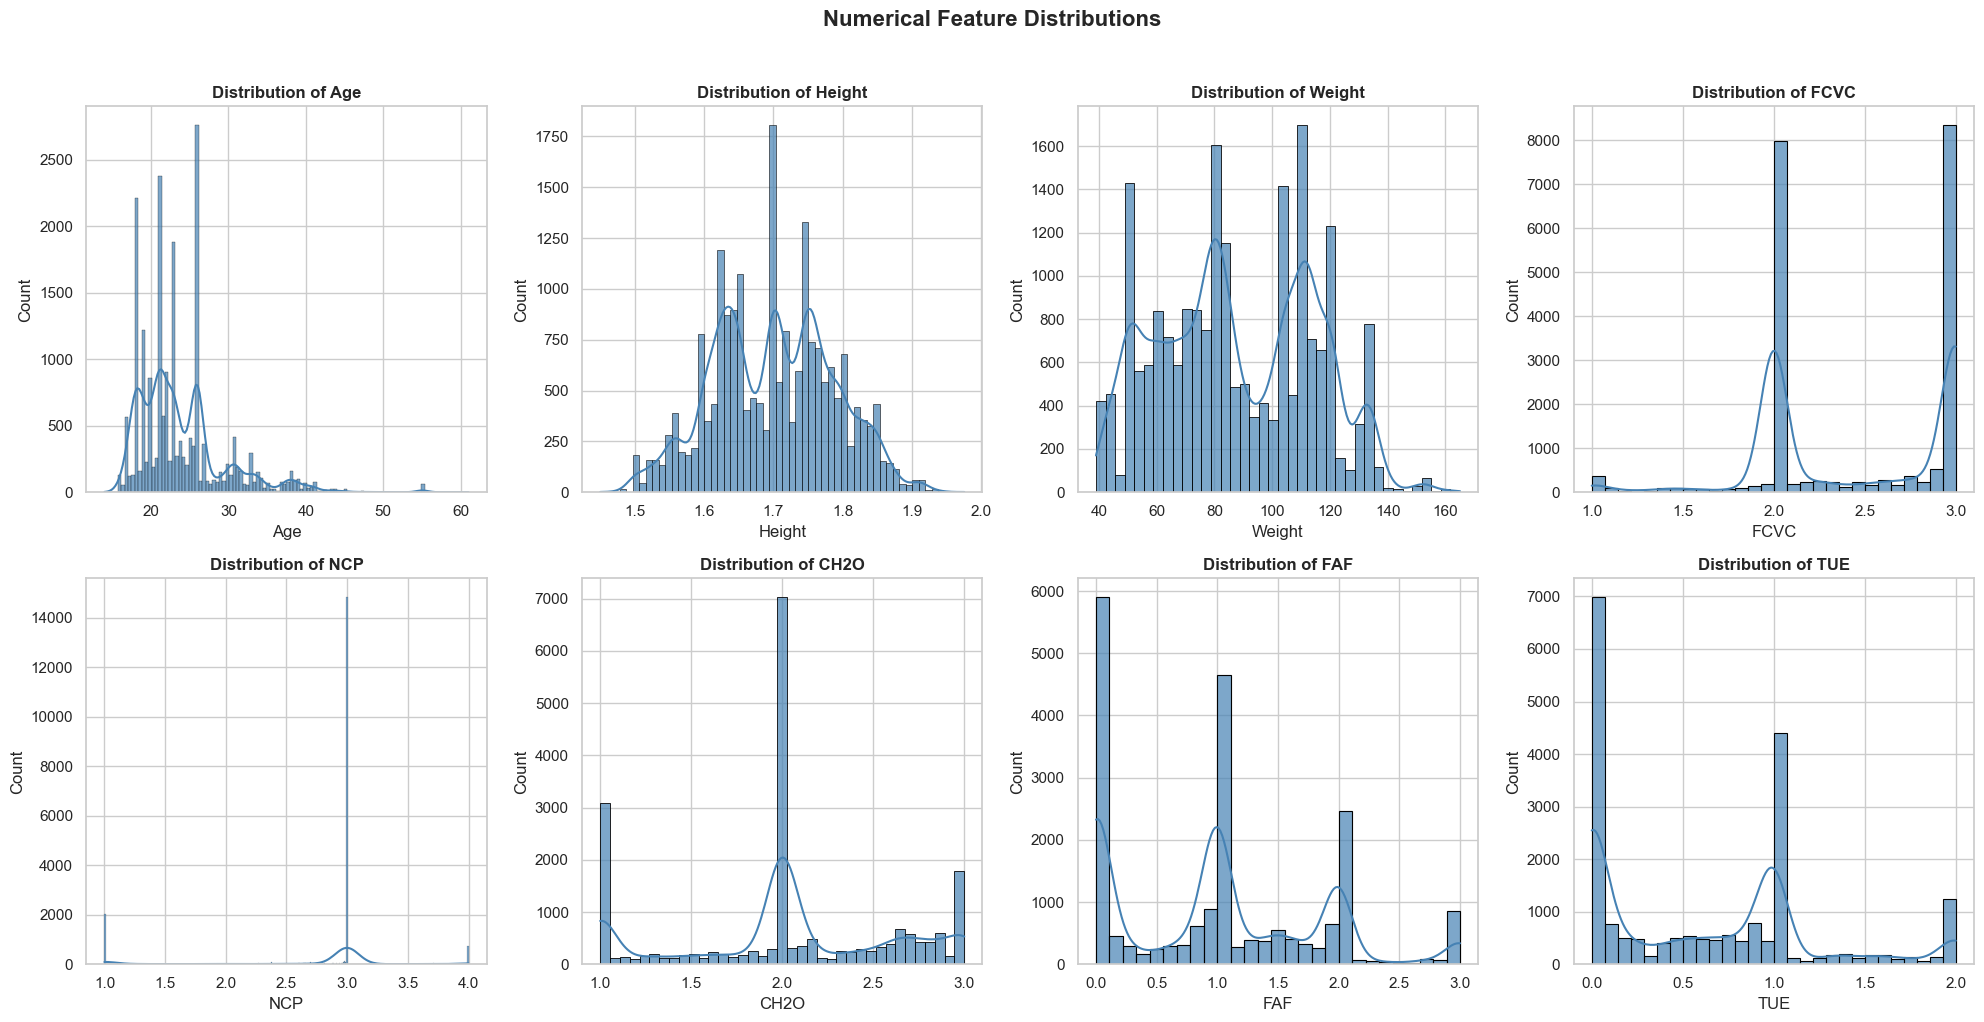

In [7]:
num_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for i, col in enumerate(num_cols):
    ax = axes[i // 4, i % 4]
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
plt.suptitle('Numerical Feature Distributions', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3.4 Correlation Analysis

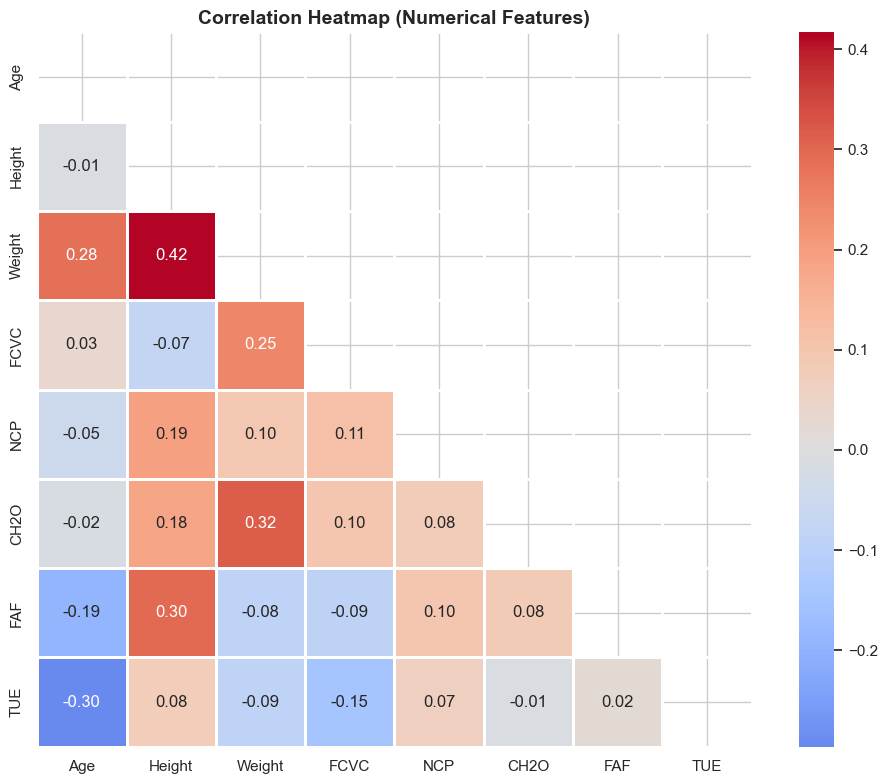

In [8]:
fig, ax = plt.subplots(figsize=(10, 8))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, square=True, linewidths=1, ax=ax)
ax.set_title('Correlation Heatmap (Numerical Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.5 Weight vs Height by Obesity Level

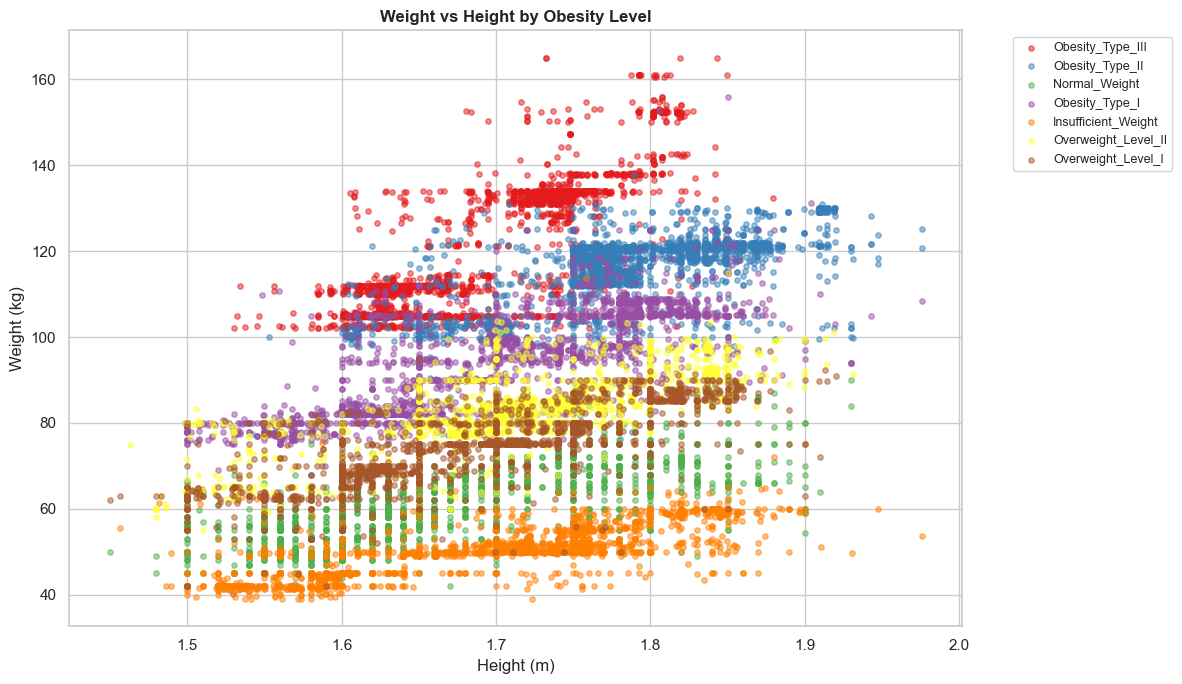

In [9]:
fig, ax = plt.subplots(figsize=(12, 7))
order_labels = df['Obesity_Level'].value_counts().index.tolist()
palette = sns.color_palette('Set1', n_colors=len(order_labels))
for idx, level in enumerate(order_labels):
    subset = df[df['Obesity_Level'] == level]
    ax.scatter(subset['Height'], subset['Weight'], alpha=0.5, s=15,
               label=level, color=palette[idx])
ax.set_xlabel('Height (m)')
ax.set_ylabel('Weight (kg)')
ax.set_title('Weight vs Height by Obesity Level', fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

## 4. Data Cleaning & Preprocessing

- No missing values (20,758 rows).
- No duplicate rows.
- Corrupted target name (`0be1dad`) and values (`0rmal_Weight`, `0`) were already fixed at load time.
- Non-predictive `id` column is dropped.
- Categorical features are encoded **inside the modelling `Pipeline`** (one-hot), so no manual encoding is needed here.

In [10]:
print('Rows before cleaning:', len(df))
print('Missing values:', df.isnull().sum().sum())
print('Duplicates:', df.duplicated().sum())

Rows before cleaning: 20758
Missing values: 0
Duplicates: 0


In [11]:
# Drop the non-predictive id column (no duplicates to worry about here)
df = df.drop('id', axis=1)
print('Rows after cleaning:', len(df))

Rows after cleaning: 20758


In [12]:
# Separate features and target
X = df.drop('Obesity_Level', axis=1)
y = df['Obesity_Level']

print('Features:', X.shape[1])
print('Target classes:', np.unique(y))
print('\nX head:')
X.head()

Features: 16
Target classes: ['Insufficient_Weight' 'Normal_Weight' 'Obesity_Type_I' 'Obesity_Type_II'
 'Obesity_Type_III' 'Overweight_Level_I' 'Overweight_Level_II']

X head:


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS
0,Male,24.443011,1.699998,81.669950,1,1,2.000000,2.983297,Sometimes,0,2.763573,0,0.000000,0.976473,Sometimes,Public_Transportation
1,Female,18.000000,1.560000,57.000000,1,1,2.000000,3.000000,Frequently,0,2.000000,0,1.000000,1.000000,Never,Automobile
2,Female,18.000000,1.711460,50.165754,1,1,1.880534,1.411685,Sometimes,0,1.910378,0,0.866045,1.673584,Never,Public_Transportation
3,Female,20.952737,1.710730,131.274851,1,1,3.000000,3.000000,Sometimes,0,1.674061,0,1.467863,0.780199,Sometimes,Public_Transportation
4,Male,31.641081,1.914186,93.798055,1,1,2.679664,1.971472,Sometimes,0,1.979848,0,1.967973,0.931721,Sometimes,Public_Transportation


In [13]:
# Train/test split (stratified, 70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f'Training set: {X_train.shape}')
print(f'Test set: {X_test.shape}')
print(f'\nTrain target distribution:\n{y_train.value_counts(normalize=True).round(3)}')

Training set: (14530, 16)
Test set: (6228, 16)

Train target distribution:
Obesity_Level
Obesity_Type_III       0.195
Obesity_Type_II        0.157
Normal_Weight          0.148
Obesity_Type_I         0.140
Insufficient_Weight    0.122
Overweight_Level_II    0.121
Overweight_Level_I     0.117
Name: proportion, dtype: float64


## 5. Modelling Framework

We build a **ColumnTransformer + Pipeline** so that:
1. Any missing values are imputed (`median` for numeric, `most_frequent` for categorical).
2. Numeric features are standardized with `StandardScaler`.
3. Categorical features are one-hot encoded.

This keeps everything in one clean, reusable object.

In [14]:
numeric_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
categorical_cols = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC',
                    'SMOKE', 'SCC', 'CALC', 'MTRANS']

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), categorical_cols)
])

print('Preprocessor defined')

Preprocessor defined


### 5.1 Cross-Validation Comparison of Baseline Models

> ⏱️ Runtime note: baselines use 5-fold Stratified CV. GridSearchCV uses **3-fold** CV during tuning (documented trade-off for runtime).
>
> Since the target is **multiclass (7 classes)**, ROC-AUC is reported as the **one-vs-rest** average, and F1 is reported as `weighted`.

In [15]:
# Define candidate models
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Linear SVM':          SVC(kernel='linear', probability=True, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=42),
}

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}
print(f'{"Model":<20}{"Acc":<10}{"F1":<10}{"ROC-AUC":<10}')
print('-' * 50)
for name, model in models.items():
    pipe = Pipeline([('prepro', preprocessor), ('model', model)])
    scores = cross_validate(pipe, X_train, y_train, cv=cv5,
                            scoring={'accuracy': 'accuracy',
                                     'f1_weighted': 'f1_weighted',
                                     'roc_auc_ovr': 'roc_auc_ovr'},
                            n_jobs=-1)
    results[name] = {
        'accuracy': scores['test_accuracy'].mean(),
        'f1_weighted': scores['test_f1_weighted'].mean(),
        'roc_auc_ovr': scores['test_roc_auc_ovr'].mean()
    }
    print(f'{name:<20}{results[name]["accuracy"]:.3f}    {results[name]["f1_weighted"]:.3f}     {results[name]["roc_auc_ovr"]:.3f}')

best_base = max(results, key=lambda k: results[k]['roc_auc_ovr'])
print(f'\nBest baseline model: {best_base}')

Model               Acc       F1        ROC-AUC   
--------------------------------------------------
Logistic Regression 0.860    0.858     0.979
Linear SVM          0.870    0.869     0.981
Decision Tree       0.844    0.844     0.902
Random Forest       0.886    0.885     0.984
Gradient Boosting   0.901    0.901     0.988

Best baseline model: Gradient Boosting


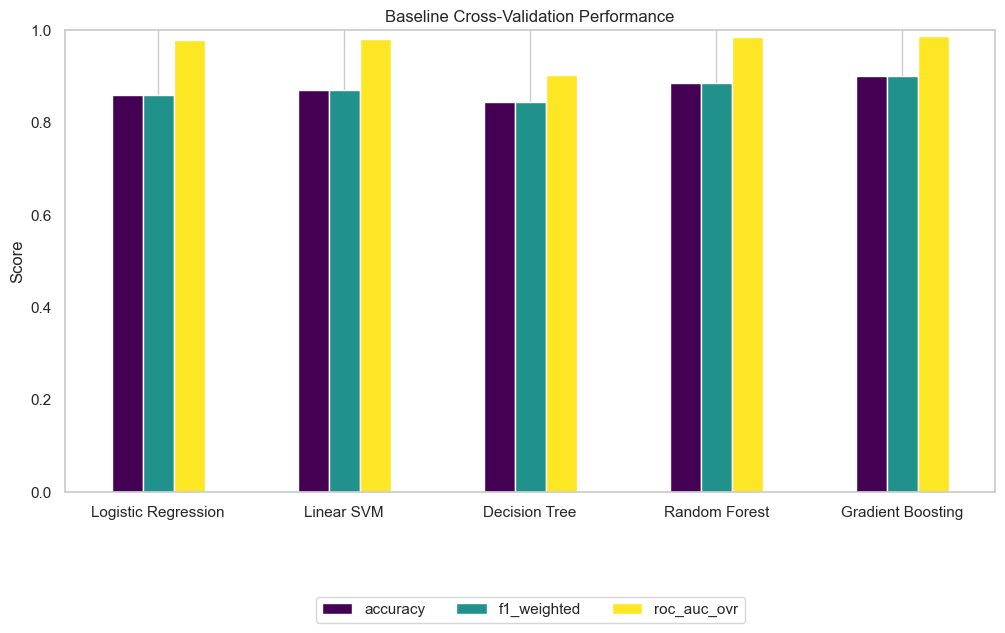

In [16]:
# Visualize baseline CV performance
baseline_df = pd.DataFrame(results).T
baseline_df.plot(kind='bar', figsize=(12, 6), rot=0, colormap='viridis')
plt.title('Baseline Cross-Validation Performance')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.3), ncol=3)
plt.grid(axis='y')
plt.show()

## 6. Hyperparameter Tuning (GridSearchCV)

We tune the most promising models with **3-fold CV**, optimising the ROC-AUC (one-vs-rest).

In [17]:
cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Tune Logistic Regression
lr_param_grid = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__solver': ['lbfgs']
}

pipe_lr = Pipeline([('prepro', preprocessor), ('model', LogisticRegression(max_iter=2000, random_state=42))])
lr_grid = GridSearchCV(pipe_lr, lr_param_grid, cv=cv3, scoring='roc_auc_ovr', n_jobs=-1)
lr_grid.fit(X_train, y_train)

print('Best Logistic Regression params:', lr_grid.best_params_)
print('Best CV ROC-AUC: {:.4f}'.format(lr_grid.best_score_))

Best Logistic Regression params: {'model__C': 10, 'model__solver': 'lbfgs'}
Best CV ROC-AUC: 0.9799


In [18]:
# Tune Linear SVM
svm_param_grid = {
    'model__C': [0.1, 1, 10]
}

pipe_svm = Pipeline([('prepro', preprocessor), ('model', SVC(kernel='linear', probability=True, random_state=42))])
svm_grid = GridSearchCV(pipe_svm, svm_param_grid, cv=cv3, scoring='roc_auc_ovr', n_jobs=-1)
svm_grid.fit(X_train, y_train)

print('Best Linear SVM params:', svm_grid.best_params_)
print('Best CV ROC-AUC: {:.4f}'.format(svm_grid.best_score_))

Best Linear SVM params: {'model__C': 1}
Best CV ROC-AUC: 0.9805


In [19]:
# Tune Random Forest
rf_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [10, None],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

pipe_rf = Pipeline([('prepro', preprocessor), ('model', RandomForestClassifier(random_state=42))])
rf_grid = GridSearchCV(pipe_rf, rf_param_grid, cv=cv3, scoring='roc_auc_ovr', n_jobs=-1)
rf_grid.fit(X_train, y_train)

print('Best Random Forest params:', rf_grid.best_params_)
print('Best CV ROC-AUC: {:.4f}'.format(rf_grid.best_score_))

Best Random Forest params: {'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best CV ROC-AUC: 0.9853


In [20]:
# Tune Gradient Boosting
gb_param_grid = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.05, 0.1],
    'model__max_depth': [3, 5]
}

pipe_gb = Pipeline([('prepro', preprocessor), ('model', GradientBoostingClassifier(random_state=42))])
gb_grid = GridSearchCV(pipe_gb, gb_param_grid, cv=cv3, scoring='roc_auc_ovr', n_jobs=-1)
gb_grid.fit(X_train, y_train)

print('Best Gradient Boosting params:', gb_grid.best_params_)
print('Best CV ROC-AUC: {:.4f}'.format(gb_grid.best_score_))

Best Gradient Boosting params: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200}
Best CV ROC-AUC: 0.9881


## 7. Compare Tuned Models & Select the Best

The tuned estimators are re-scored with **5-fold Stratified CV** for a fair final comparison; the winner is selected by ROC-AUC (one-vs-rest).

In [21]:
# Collect tuned models
tuned_models = {
    'Logistic Regression': lr_grid.best_estimator_,
    'Linear SVM':          svm_grid.best_estimator_,
    'Random Forest':       rf_grid.best_estimator_,
    'Gradient Boosting':   gb_grid.best_estimator_,
}

grid_lookup = {'Logistic Regression': lr_grid, 'Linear SVM': svm_grid,
               'Random Forest': rf_grid, 'Gradient Boosting': gb_grid}

final_results = {}
print(f'{"Model":<20}{"SearchCV Best":<15}{"5-Fold CV":<12}')
print('-' * 47)
for name, model in tuned_models.items():
    grid_best = grid_lookup[name].best_score_
    scores = cross_val_score(model, X_train, y_train, cv=cv5, scoring='roc_auc_ovr', n_jobs=-1)
    final_results[name] = scores.mean()
    print(f'{name:<20}{grid_best:.4f}        {scores.mean():.4f}')

best_name = max(final_results, key=final_results.get)
best_model = tuned_models[best_name]
print(f'\n🏆 Best model: {best_name} (5-fold CV ROC-AUC = {final_results[best_name]:.4f})')

Model               SearchCV Best  5-Fold CV   
-----------------------------------------------
Logistic Regression 0.9799        0.9801
Linear SVM          0.9805        0.9806
Random Forest       0.9853        0.9857
Gradient Boosting   0.9881        0.9885

🏆 Best model: Gradient Boosting (5-fold CV ROC-AUC = 0.9885)


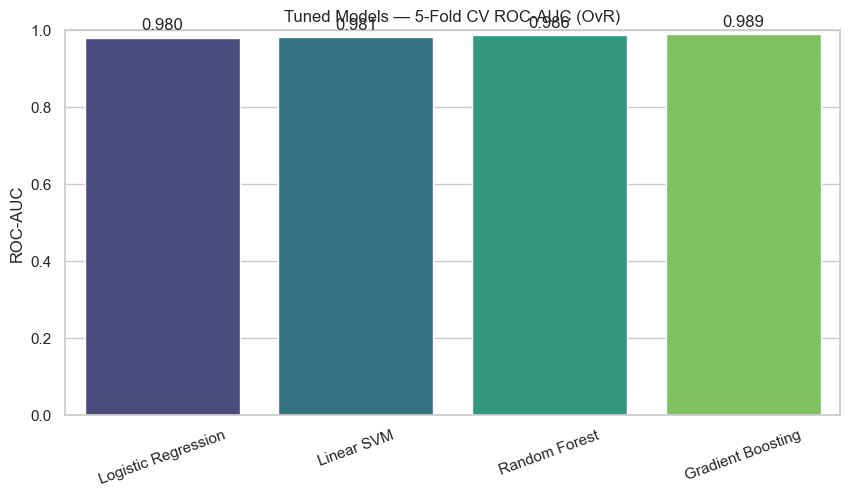

In [22]:
# Plot comparison
plt.figure(figsize=(10, 5))
sns.barplot(x=list(final_results.keys()), y=list(final_results.values()), palette='viridis')
plt.title('Tuned Models — 5-Fold CV ROC-AUC (OvR)')
plt.ylabel('ROC-AUC')
plt.ylim(0, 1)
plt.xticks(rotation=20)
for i, v in enumerate(final_results.values()):
    plt.text(i, v + 0.02, f'{v:.3f}', ha='center')
plt.show()

## 8. Evaluate the Best Model on the Holdout Test Set

In [23]:
# Predict on test set
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)

print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=best_model.classes_))

print('Metrics:')
print(f'Accuracy      : {accuracy_score(y_test, y_pred):.4f}')
print(f'F1 (weighted) : {f1_score(y_test, y_pred, average="weighted"):.4f}')
print(f'F1 (macro)    : {f1_score(y_test, y_pred, average="macro"):.4f}')
print(f'ROC-AUC (OvR) : {roc_auc_score(y_test, y_proba, multi_class="ovr"):.4f}')

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.92      0.95      0.93       757
      Normal_Weight       0.89      0.88      0.88       925
     Obesity_Type_I       0.88      0.88      0.88       873
    Obesity_Type_II       0.96      0.97      0.96       974
   Obesity_Type_III       1.00      1.00      1.00      1214
 Overweight_Level_I       0.81      0.79      0.80       728
Overweight_Level_II       0.81      0.82      0.81       757

           accuracy                           0.91      6228
          macro avg       0.90      0.90      0.90      6228
       weighted avg       0.91      0.91      0.91      6228

Metrics:
Accuracy      : 0.9059
F1 (weighted) : 0.9056
F1 (macro)    : 0.8960
ROC-AUC (OvR) : 0.9897


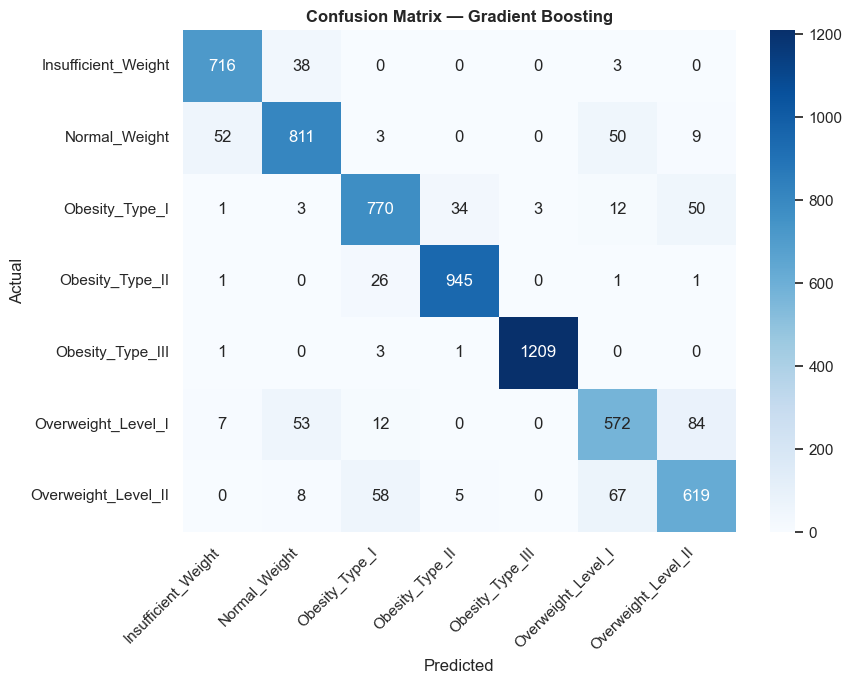

In [24]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(9, 7))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=best_model.classes_, yticklabels=best_model.classes_, ax=ax)
ax.set_title(f'Confusion Matrix — {best_name}', fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

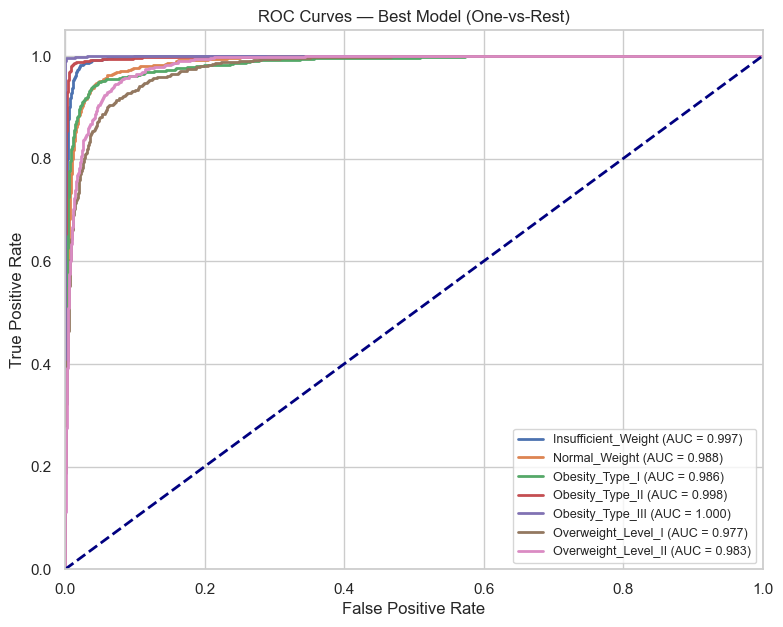

In [25]:
# ROC Curves (one-vs-rest per class)
classes = best_model.classes_
y_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(9, 7))
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
    plt.plot(fpr, tpr, lw=2, label=f'{cls} (AUC = {auc(fpr, tpr):.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Best Model (One-vs-Rest)')
plt.legend(loc='lower right', fontsize=9)
plt.grid(True)
plt.show()

## 9. Feature Importance (for the best tree-based model)

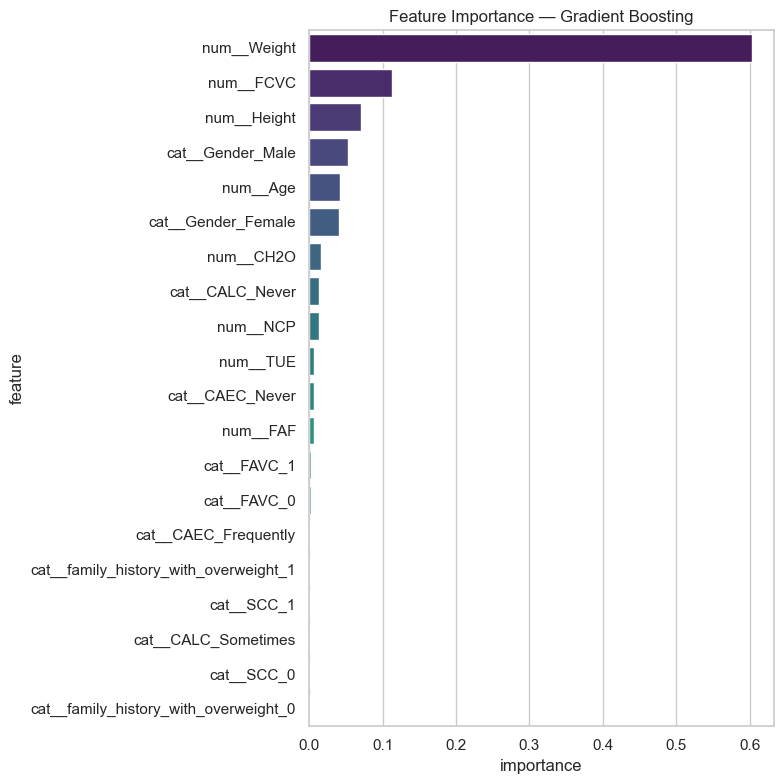

In [26]:
# Feature importance if tree-based
if hasattr(best_model.named_steps['model'], 'feature_importances_'):
    importances = best_model.named_steps['model'].feature_importances_
    feat_names = best_model.named_steps['prepro'].get_feature_names_out()

    imp_df = pd.DataFrame({'feature': feat_names, 'importance': importances})
    imp_df = imp_df.sort_values('importance', ascending=False)

    plt.figure(figsize=(8, 8))
    sns.barplot(data=imp_df.head(20), x='importance', y='feature', palette='viridis')
    plt.title(f'Feature Importance — {best_name}')
    plt.tight_layout()
    plt.show()
else:
    print(f'{best_name} is not a tree-based model; feature importance not available directly.')

## 10. Conclusion & Summary

- **Dataset**: 20,758 rows → 16 features (demographics, eating habits, physical activity) after dropping the non-predictive `id` column. No missing values, no duplicates.
- **Target**: `Obesity_Level` — 7 ordered classes from `Insufficient_Weight` to `Obesity_Type_III`, fairly balanced.
- **Cleaning**: corrupted column name (`0be1dad`) and strings (`0rmal_Weight`, `0`) fixed at load time.
- **Best model**: selected via GridSearchCV tuning + Stratified K-Fold CV, judged by multiclass ROC-AUC (one-vs-rest).

### Key findings from EDA:
- **Weight** and **Age** are the strongest drivers of higher obesity levels; the `Weight`-vs-`Height` scatter separates most classes cleanly.
- Eating / activity habit features (`FAF`, `FCVC`, `NCP`) carry smaller, secondary signal.
- No strong multicollinearity among the numerical features (apart from the expected `Weight`–`Height` relationship).

In [27]:
from IPython.display import display, Markdown

display(Markdown(f'''
## Final Model
- **Best model**: **{best_name}** with a 5-fold CV ROC-AUC of **{final_results[best_name]:.3f}**.
- All preprocessing (imputation + scaling + one-hot encoding) is encapsulated in an sklearn `Pipeline`, making it fully reusable and deployment-ready.
- Test-set ROC-AUC (OvR): **{roc_auc_score(y_test, y_proba, multi_class="ovr"):.3f}**
'''))


## Final Model
- **Best model**: **Gradient Boosting** with a 5-fold CV ROC-AUC of **0.989**.
- All preprocessing (imputation + scaling + one-hot encoding) is encapsulated in an sklearn `Pipeline`, making it fully reusable and deployment-ready.
- Test-set ROC-AUC (OvR): **0.990**


In [28]:
# Save the full pipeline for reuse
import joblib
joblib.dump(best_model, 'best_obesity_model.pkl')
print(f'Saved best pipeline ({best_name}) to best_obesity_model.pkl')
print('\nPipeline:')
print(best_model)

Saved best pipeline (Gradient Boosting) to best_obesity_model.pkl

Pipeline:
Pipeline(steps=[('prepro',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Height', 'Weight',
                                                   'FCVC', 'NCP', 'CH2O', 'FAF',
                                                   'TUE']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                               